Решение методом Ньютона:
+-----+----------+-----------+----------+
|   n |     x1^n |      x2^n |      ε_n |
+=====+==========+===========+==========+
|   0 | 0.000000 |  0.000000 | 0.832109 |
+-----+----------+-----------+----------+
|   1 | 0.595869 | -0.197650 | 0.113403 |
+-----+----------+-----------+----------+
|   2 | 0.655903 | -0.283222 | 0.002756 |
+-----+----------+-----------+----------+
|   3 | 0.655132 | -0.285152 | 0.000001 |
+-----+----------+-----------+----------+

Проверка решения методом Ньютона:
f1(0.6551316650428637, -0.28515159464242784) = 1.217466087832797e-06
f2(0.6551316650428637, -0.28515159464242784) = -2.719066016787508e-07

Решение методом простых итераций:
+-----+----------+-----------+----------+
|   n |     x1^n |      x2^n |      ε_n |
+=====+==========+===========+==========+
|   0 | 0.000000 |  0.000000 | 0.000000 |
+-----+----------+-----------+----------+
|   1 | 0.416147 | -0.720574 | 0.832109 |
+-----+----------+-----------+----------+
|   2 | 0.

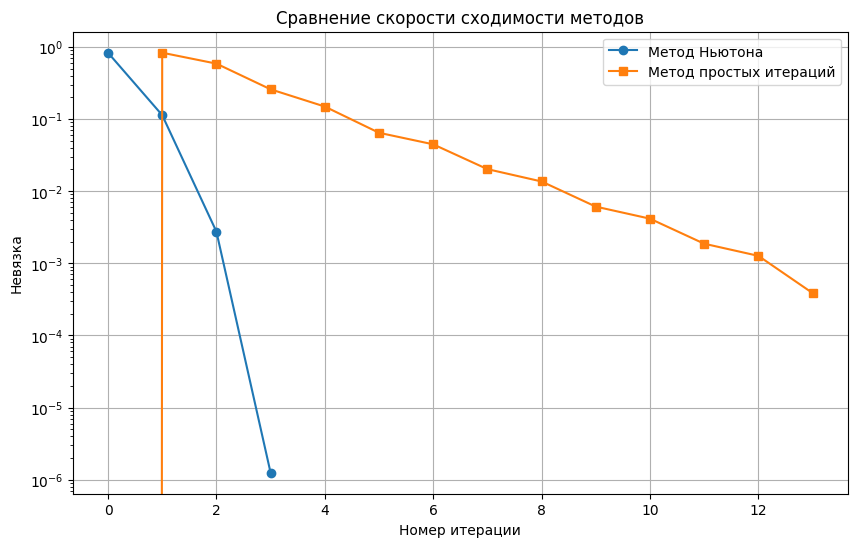


Сравнение методов:
Метод Ньютона: 4 итераций
Метод простых итераций: 14 итераций

Решение методом Ньютона: x1 = 0.655132, x2 = -0.285152
Решение методом простых итераций: x1 = 0.654918, x2 = -0.285358


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

def f1(x1, x2):
    """Первая функция системы: cos(x2 - 2) + x1 = 0"""
    return np.cos(x2 - 2) + x1

def f2(x1, x2):
    """Вторая функция системы: sin(x1 + 0.5) - x2 - 1.2 = 0"""
    return np.sin(x1 + 0.5) - x2 - 1.2

def jacob(x1, x2):
    """Матрица Якоби для системы"""
    j11 = 1
    j12 = -np.sin(x2 - 2)
    j21 = np.cos(x1 + 0.5)
    j22 = -1
    return np.array([[j11, j12], [j21, j22]])

def newton_method(x0, eps=1e-3, max_iter=100):
    """Метод Ньютона для решения системы нелинейных уравнений"""
    x = np.array(x0, dtype=float)
    iterations = []

    for n in range(max_iter):
        # Сохраняем текущее приближение для таблицы
        x1, x2 = x

        # Вычисляем значения функций
        f = np.array([f1(x1, x2), f2(x1, x2)])

        # Вычисляем норму невязки
        error = np.linalg.norm(f)

        # Сохраняем информацию об итерации
        iterations.append({
            'n': n,
            'x1': x1,
            'x2': x2,
            'error': error
        })

        # Проверяем условие сходимости
        if error < eps:
            break

        # Вычисляем матрицу Якоби
        j = jacob(x1, x2)

        # Решаем СЛАУ для приращения
        try:
            delta = np.linalg.solve(j, -f)
        except np.linalg.LinAlgError:
            print("Невозможно обратить матрицу Якоби")
            break

        # Обновляем приближение
        x = x + delta

    return x, iterations

def simple_iteration_method(x0, eps=1e-3, max_iter=100):
    """Метод простых итераций для решения системы нелинейных уравнений"""
    x = np.array(x0, dtype=float)
    iterations = []

    for n in range(max_iter):
        # Сохраняем текущее приближение
        x1, x2 = x

        # Сохраняем информацию об итерации
        iterations.append({
            'n': n,
            'x1': x1,
            'x2': x2,
            'error': 0 if n == 0 else np.linalg.norm(x - x_prev)
        })

        # Проверка сходимости (начиная со второй итерации)
        if n > 0 and np.linalg.norm(x - x_prev) < eps:
            break

        # Сохраняем текущее приближение для сравнения
        x_prev = x.copy()

        # Вычисляем новое приближение
        x = np.array([
            -np.cos(x2 - 2),
            np.sin(x1 + 0.5) - 1.2
        ])

    # Проверяем, являются ли полученные значения корнями системы
    x1, x2 = x
    error = np.linalg.norm([f1(x1, x2), f2(x1, x2)])
    iterations[-1]['error'] = error

    return x, iterations

def print_iterations_table(iterations):
    """Вывод таблицы итераций"""
    table = []
    for it in iterations:
        table.append([it['n'], it['x1'], it['x2'], it['error']])

    headers = ['n', 'x1^n', 'x2^n', 'ε_n']
    print(tabulate(table, headers=headers, tablefmt='grid', floatfmt='.6f'))

def check_solution(x, method_name):
    """Проверка решения"""
    x1, x2 = x
    print(f"\nПроверка решения методом {method_name}:")
    print(f"f1({x1}, {x2}) = {f1(x1, x2)}")
    print(f"f2({x1}, {x2}) = {f2(x1, x2)}")

def plot_convergence(newton_iterations, simple_iterations):
    """Визуализация скорости сходимости методов"""
    newton_errors = [it['error'] for it in newton_iterations]
    simple_errors = [it['error'] for it in simple_iterations]

    plt.figure(figsize=(10, 6))
    plt.semilogy(range(len(newton_errors)), newton_errors, 'o-', label='Метод Ньютона')
    plt.semilogy(range(len(simple_errors)), simple_errors, 's-', label='Метод простых итераций')
    plt.xlabel('Номер итерации')
    plt.ylabel('Невязка')
    plt.grid(True)
    plt.legend()
    plt.title('Сравнение скорости сходимости методов')
    plt.savefig('convergence_comparison.png')
    plt.show()

# Начальное приближение
x0 = [0, 0]
eps = 1e-3

# Решение методом Ньютона
print("Решение методом Ньютона:")
newton_solution, newton_iterations = newton_method(x0, eps)
print_iterations_table(newton_iterations)
check_solution(newton_solution, "Ньютона")

# Решение методом простых итераций
print("\nРешение методом простых итераций:")
simple_solution, simple_iterations = simple_iteration_method(x0, eps)
print_iterations_table(simple_iterations)
check_solution(simple_solution, "простых итераций")

# Сравнение скорости сходимости
plot_convergence(newton_iterations, simple_iterations)

# Вывод результатов
print("\nСравнение методов:")
print(f"Метод Ньютона: {len(newton_iterations)} итераций")
print(f"Метод простых итераций: {len(simple_iterations)} итераций")
print(f"\nРешение методом Ньютона: x1 = {newton_solution[0]:.6f}, x2 = {newton_solution[1]:.6f}")
print(f"Решение методом простых итераций: x1 = {simple_solution[0]:.6f}, x2 = {simple_solution[1]:.6f}")